In [ ]:
import pandas as pd

df = pd.read_csv("data.json")

print(df.to_string())



In [20]:
import pandas as pd
import numpy as np

# Create a sample DataFrame
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Emma', 'Frank'],
    'Age': [25, 30, 35, 28, 32, 29],
    'City': ['New York', 'Boston', 'New York', 'Chicago', 'Boston', 'Chicago'],
    'Salary': [50000, 60000, 75000, 55000, 65000, 58000],
    'Department': ['HR', 'IT', 'IT', 'Finance', 'HR', 'Finance']
}, index=['a', 'b', 'c', 'd', 'e', 'f'])

#print("Original DataFrame:")
#print(df)
#print("Single column:")
#print(df['Name'])
#print(df.Name)  # Alternative syntax
#print(type(df['Name']))  # pandas Series

#print("\nMultiple columns:")
#print(df[['Name', 'Age', 'Salary']])

# Selecting columns with loc (label-based)
#print("\nSelecting columns with loc:")
#print(df.loc[:, ['Name', 'City']])
#print("\nSelecting columns with iloc:")
#print(df.iloc[:, [0, 2, 4]])  # First, third, and fifth columns
#print(df.iloc[:, 0:3])  # First three columns

'''print("\nNames starting with 'A':")
print(df[df['Name'].str.startswith('A')])

print("\nNames containing 'e':")
print(df[df['Name'].str.contains('e', case=False)])

# Between condition
print("\nAge between 25 and 30:")
print(df[df['Age'].between(25, 30)])

# Null/Not null conditions
df_with_nan = df.copy()
df_with_nan.loc['b', 'Salary'] = np.nan
print("\nRows with null values:")
print(df_with_nan[df_with_nan['Salary'].isna()])
print("\nRows without null values:")
print(df_with_nan[df_with_nan['Salary'].notna()])'''

#print("Setting Name as index:")
#df_name_index = df.set_index('Name')
#print(df_name_index)

# Resetting index
#print("\nResetting index:")
#df_reset = df_name_index.reset_index()
#print(df_reset)

# Setting index without dropping
'''print("\nSetting index without dropping original column:")
df_index = df.set_index('Name', drop=False)
print(df_index)

# Multiple index (MultiIndex)
print("\nSetting multi-level index:")
df_multi = df.set_index(['Department', 'City'])
print(df_multi)
print("\nSelecting from MultiIndex:")
print(df_multi.loc['IT'])  # All IT department employees
print(df_multi.loc[('IT', 'New York')])  # Specific combination

# Sorting index
print("\nSorting by index:")
df_sorted = df.set_index('Name').sort_index()
print(df_sorted)'''

# Reindexing
#print("Reindexing with new index:")
#new_index = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
#df_reindexed = df.reindex(new_index)
#print(df_reindexed)

# Fill missing values when reindexing
'''df_reindexed_filled = df.reindex(new_index, fill_value='Unknown')
print("\nReindexed with fill value:")
print(df_reindexed_filled)

# Using where() method
print("\nUsing where() to conditionally replace:")
df_where = df.copy()
df_where['Salary'] = df_where['Salary'].where(df_where['Salary'] > 60000, other=60000)
print(df_where)

# Using mask() (opposite of where)
print("\nUsing mask():")
df_mask = df.copy()
df_mask['Salary'] = df_mask['Salary'].mask(df_mask['Salary'] < 60000, other=70000)
print(df_mask)'''

#print(df)
#print(f"\nShape: {df.shape}")
#print(f"Index: {df.index}")
#print(f"Columns: {df.columns.tolist()}")
#  print(df.describe(include='all'))

# unique() - Get unique values in a column
print("Unique Departments:")
print(df['Department'].unique())

# nunique() - Count unique values
'''print(f"\nNumber of unique departments: {df['Department'].nunique()}")
print(f"Number of unique cities: {df['City'].nunique()}")

# value_counts() - Frequency counts
print("\nDepartment Distribution:")
print(df['Department'].value_counts())

print("\nCity Distribution:")
print(df['City'].value_counts())'''

# value_counts with percentages
'''print("\nCity Distribution (percentages):")
print(df['City'].value_counts(normalize=True))

# value_counts with sorting
print("\nDepartment Distribution (sorted by index):")
print(df['Department'].value_counts().sort_index())'''

# value_counts with bins for numeric data
#print("\nAge Distribution (binned):")
#print(df['Age'].value_counts(bins=3))

# value_counts with dropna
#print("\nDepartment Distribution (including NaN):")
#df_with_nan = df.copy()
#df_with_nan.loc[0, 'Department'] = np.nan
#print(df_with_nan['Department'].value_counts(dropna=False))

def categorize_salary(salary):
    if salary < 55000:
        return 'Low'
    elif salary < 65000:
        return 'Medium'
    else:
        return 'High'

df['Salary_Category'] = df['Salary'].apply(categorize_salary)
print("\nSalary Categories:")
print(df[['Name', 'Salary', 'Salary_Category']].head())


Unique Departments:
<StringArray>
['HR', 'IT', 'Finance']
Length: 3, dtype: str

Salary Categories:
      Name  Salary Salary_Category
a    Alice   50000             Low
b      Bob   60000          Medium
c  Charlie   75000            High
d    David   55000          Medium
e     Emma   65000            High


In [23]:
print("=== Handling Missing Data in Categorical Variables ===\n")

# Create DataFrame with categorical missing data
df_cat = pd.DataFrame({
    'Category': ['A', 'B', np.nan, 'A', 'C', np.nan, 'B', 'C', np.nan, 'A'],
    'Value': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
})

#print("Original categorical data:")
#print(df_cat)

# 1. Treat missing as separate category
df_cat['Category_Filled'] = df_cat['Category'].fillna('Unknown')
#print("\nTreat missing as separate category:")
#print(df_cat)

# 2. Mode imputation
#mode_val = df_cat['Category'].mode()[0]
#df_cat['Category_Mode'] = df_cat['Category'].fillna(mode_val)
#print(f"\nMode imputation with value '{mode_val}':")
#print(df_cat)

# 3. Using most frequent category by group
df_cat['Category_Group'] = pd.cut(df_cat['Value'], bins=3, labels=['Low', 'Medium', 'High'])
df_cat['Category_Imputed'] = df_cat.groupby('Category_Group')['Category'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)
print("\nGroup-based mode imputation:")
print(df_cat)

# 4. Using indicator variable for missing
df_cat['Category_Missing_Flag'] = df_cat['Category'].isnull().astype(int)
print("\nWith missing indicator:")
print(df_cat)

=== Handling Missing Data in Categorical Variables ===


Group-based mode imputation:
  Category  Value Category_Filled Category_Group Category_Imputed
0        A     10               A            Low                A
1        B     20               B            Low                B
2      NaN     30         Unknown            Low                A
3        A     40               A            Low                A
4        C     50               C         Medium                C
5      NaN     60         Unknown         Medium                B
6        B     70               B         Medium                B
7        C     80               C           High                C
8      NaN     90         Unknown           High                A
9        A    100               A           High                A

With missing indicator:
  Category  Value Category_Filled Category_Group Category_Imputed  \
0        A     10               A            Low                A   
1        B     20        

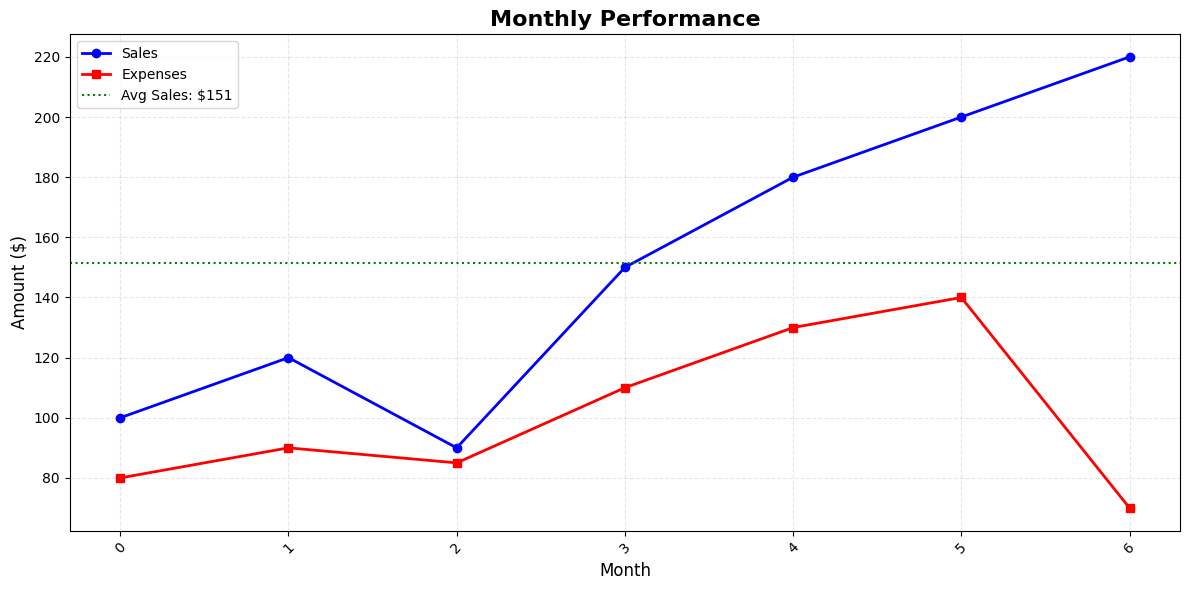

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This is always your first step - create sample data to practice
# Simple dataset to start with
df = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','jul'],
    'Sales': [100, 120, 90, 150, 180, 200,220],
    'Expenses': [80, 90, 85, 110, 130, 140,70]
})
'''plt.figure(figsize=(10, 5))  # Makes the plot bigger

# Plot sales as a line
df['Sales'].plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.grid(True)  # Adds grid lines
plt.show()

plt.figure(figsize=(10, 5))'''

# Plot sales as bars
'''df.plot(kind='bar', x='Month', y='Sales', color='skyblue')
plt.title('Monthly Sales - Bar Chart')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=30)  # Rotates month names for better readability
plt.grid(True, axis='y')  # Grid only on y-axis
plt.show()'''

scores = pd.DataFrame({
    'Exam_Scores': [85, 90, 78, 92, 88, 76, 95, 89, 84, 91, 
                    87, 82, 79, 93, 86, 88, 90, 85, 87, 91]
})

# Histogram shows how data is distributed
'''plt.figure(figsize=(10, 5))
scores['Exam_Scores'].plot(kind='hist', bins=10, color='lightgreen', edgecolor='black')
plt.title('Distribution of Exam Scores')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.grid(True, axis='y')
plt.show()'''

'''plt.figure(figsize=(10, 5))

# Plot both columns
df[['Sales', 'Expenses']].plot(kind='line', marker='o')
plt.title('Sales vs Expenses')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.grid(True)
plt.legend()  # Shows which line is which
plt.show()'''

'''plt.figure(figsize=(10, 5))
df.plot(kind='bar', x='Month', y=['Sales', 'Expenses'])
plt.title('Monthly Sales vs Expenses')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()'''

'''plt.figure(figsize=(8, 6))
df.plot(kind='scatter', x='Sales', y='Expenses', color='red', s=100)
plt.title('Relationship between Sales and Expenses')
plt.xlabel('Sales')
plt.ylabel('Expenses')
plt.grid(True)
plt.show()'''

data = pd.DataFrame({
    'Group_A': np.random.normal(100, 10, 50),
    'Group_B': np.random.normal(120, 15, 50),
    'Group_C': np.random.normal(90, 8, 50)
})

# Box plot shows min, max, median, quartiles
'''plt.figure(figsize=(10, 6))
data.plot(kind='box')
plt.title('Box Plot Comparison')
plt.ylabel('Values')
plt.grid(True, axis='y')
plt.show()'''

# Let's make a plot with all customizations we've learned
plt.figure(figsize=(12, 6))

# Create plot with multiple lines
df['Sales'].plot(kind='line', 
                 marker='o',           # Add markers
                 linewidth=2,          # Thicker line
                 color='blue',         # Line color
                 label='Sales')        # Legend label

df['Expenses'].plot(kind='line', 
                    marker='s',         # Square markers
                    linewidth=2,
                    color='red',
                    label='Expenses')

# Customize everything
plt.title('Monthly Performance', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

# Add a horizontal line at average sales
avg_sales = df['Sales'].mean()
plt.axhline(y=avg_sales, color='green', linestyle=':', label=f'Avg Sales: ${avg_sales:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
df = pd.read_json('messy_amazon_data.json')


#print(df.to_string())

#empty_rows = df[df.isnull().any(axis=1)]
#print(empty_rows)
#print(df.isnull().sum())
#print("Rows with missing values:", df.isnull().any(axis=1).sum())
#Replace_Spaces = df.replace(["", " ", "N/A"], np.nan)
#print(Replace_Spaces.to_string())
#Step 01 initial inspection
#print(df.head())
#print(df.info())
#print(df.describe(include='all'))

#sTEP 02
Replace_Spaces = df.replace(["", " ", "N/A"], np.nan)

#Step 03 Remove Duplicates
#\Rem_Dup=Replace_Spaces.drop_duplicates()
#print(Rem_Dup)

#Step 04 Filling Nan
print(Replace_Spaces['price'].isnull().sum())
Replace_Spaces['price'] = pd.to_numeric(Replace_Spaces['price'], errors='coerce')

# fill with mean
Replace_Spaces['price'] = Replace_Spaces['price'].fillna(Replace_Spaces['price'].mean())
print(Replace_Spaces)
print(Replace_Spaces['price'].isnull().sum())

200
     order_id customer_name product     category  price quantity rating  \
0         0.0          Sara  Camera          NaN  200.0        1      2   
1         1.0           Ali  Camera          NaN  100.0        3      3   
2         2.0           NaN  Tablet         ELEC  300.0      two      4   
3         3.0       Zeeshan     NaN      Gadgets  200.0        1      3   
4         4.0           NaN  Camera      Gadgets  200.0        3      3   
..        ...           ...     ...          ...    ...      ...    ...   
495     495.0           NaN  Laptop  Electronics  200.0       -1      4   
496     496.0       Zeeshan     NaN  Accessories  300.0      two      2   
497     497.0        Fatima  Laptop         ELEC  300.0       -1   five   
498     498.0        Fatima   Phone          NaN  100.0     None      1   
499     499.0       Zeeshan     NaN      Gadgets  200.0     None      4   

       order_date delivery_status  
0    March 5 2024       CANCELLED  
1      01/02/2024      

In [25]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 696.7 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/8.1 MB 696.7 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/8.1 MB 696.7 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/8.1 MB 696.7 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/8.1 MB 696.7 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.1 MB 368.7 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.1 MB 368.7 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.1 MB 368.7 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.1 MB 368.7 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.1 MB 368.7 kB/s eta 0:00:20
   --- ------